In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/student_lifestyle_dataset..csv")

In [ ]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


In [ ]:
rows, cols = df.shape
print("Number of Rows:", rows)
print("Number of Columns:", cols)

Number of Rows: 2000
Number of Columns: 9


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   object 
 7   Gender                           2000 non-null   object 
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 140.8+ KB


In [ ]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,7.789825
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.746777
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,5.600000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,7.250000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,7.780000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,8.320000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,10.000000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours_Per_Day,0
Extracurricular_Hours_Per_Day,0
Sleep_Hours_Per_Day,0
Social_Hours_Per_Day,0
Physical_Activity_Hours_Per_Day,0
Stress_Level,0
Gender,0
Grades,0


In [ ]:
df.duplicated().sum()

np.int64(0)

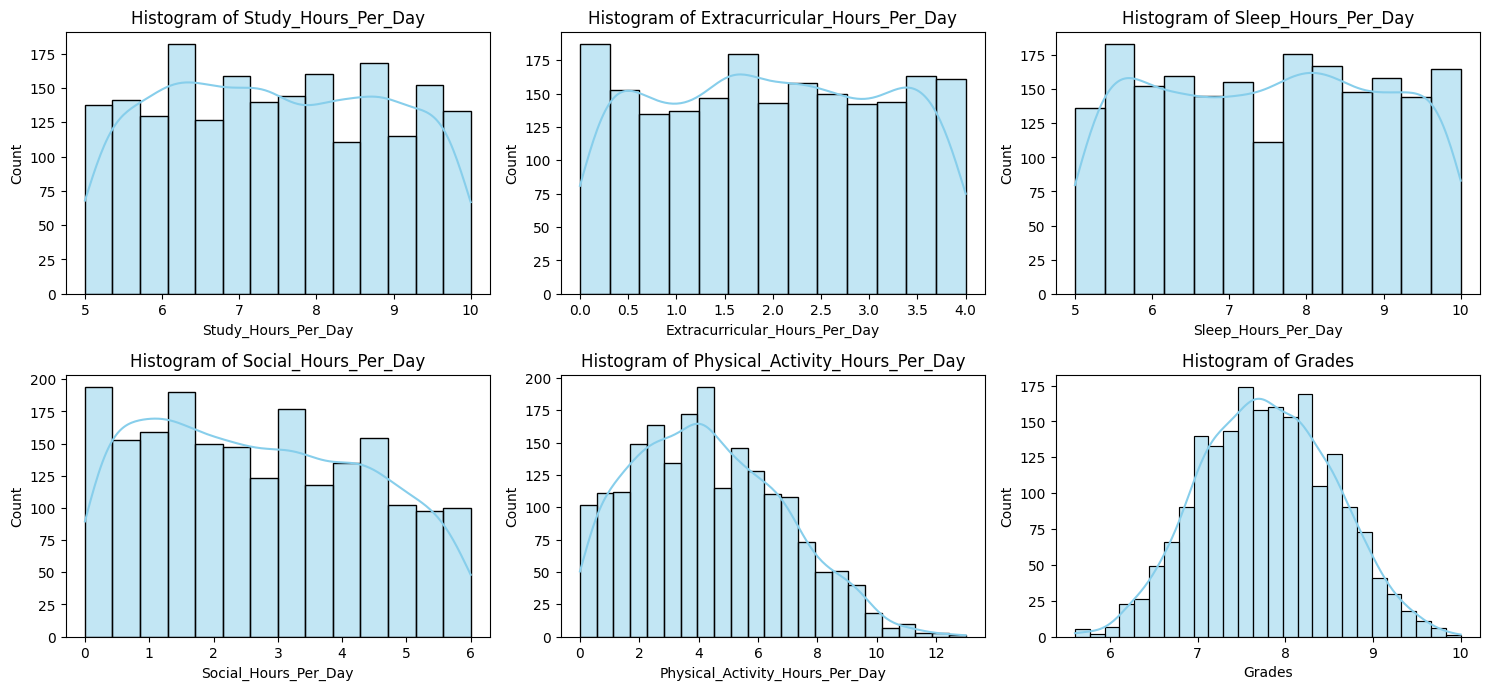

In [ ]:
numeric_df = df.select_dtypes(include=(np.float64))
numeric_columns = numeric_df.columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1000408472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')
/tmp/ipython-input-1000408472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


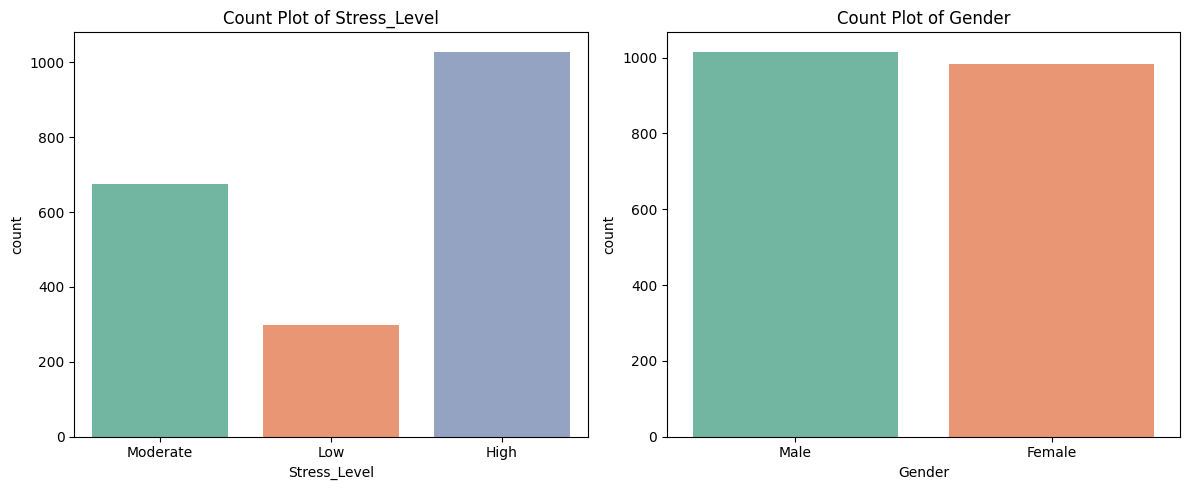

In [ ]:
categorical_cols = ['Stress_Level', 'Gender']
plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Count Plot of {col}')
plt.tight_layout()
plt.show()

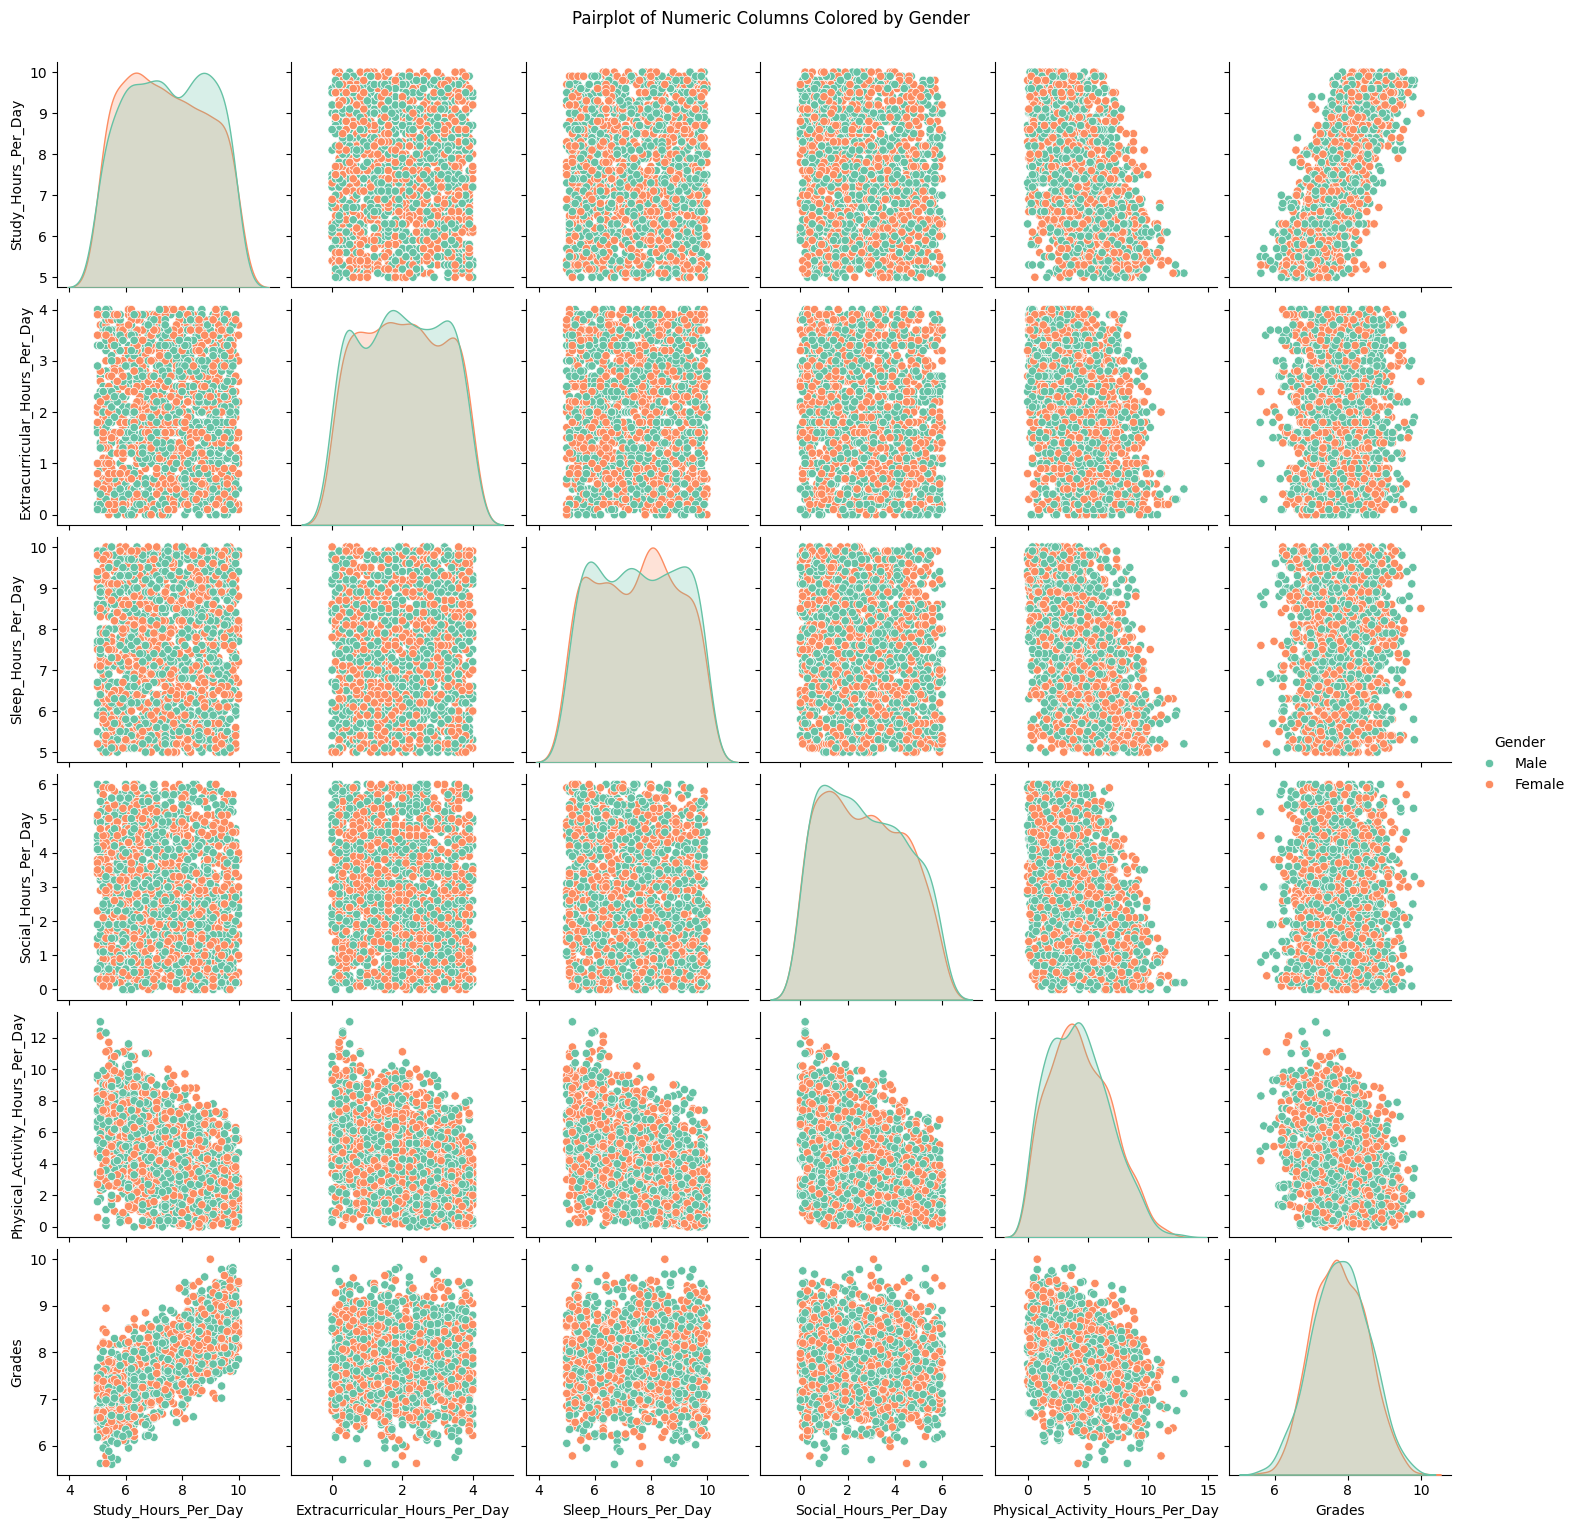

In [ ]:
sns.pairplot(df, vars=numeric_columns, hue='Gender', palette='Set2', diag_kind='kde')
plt.suptitle("Pairplot of Numeric Columns Colored by Gender ", y=1.02)
plt.show()

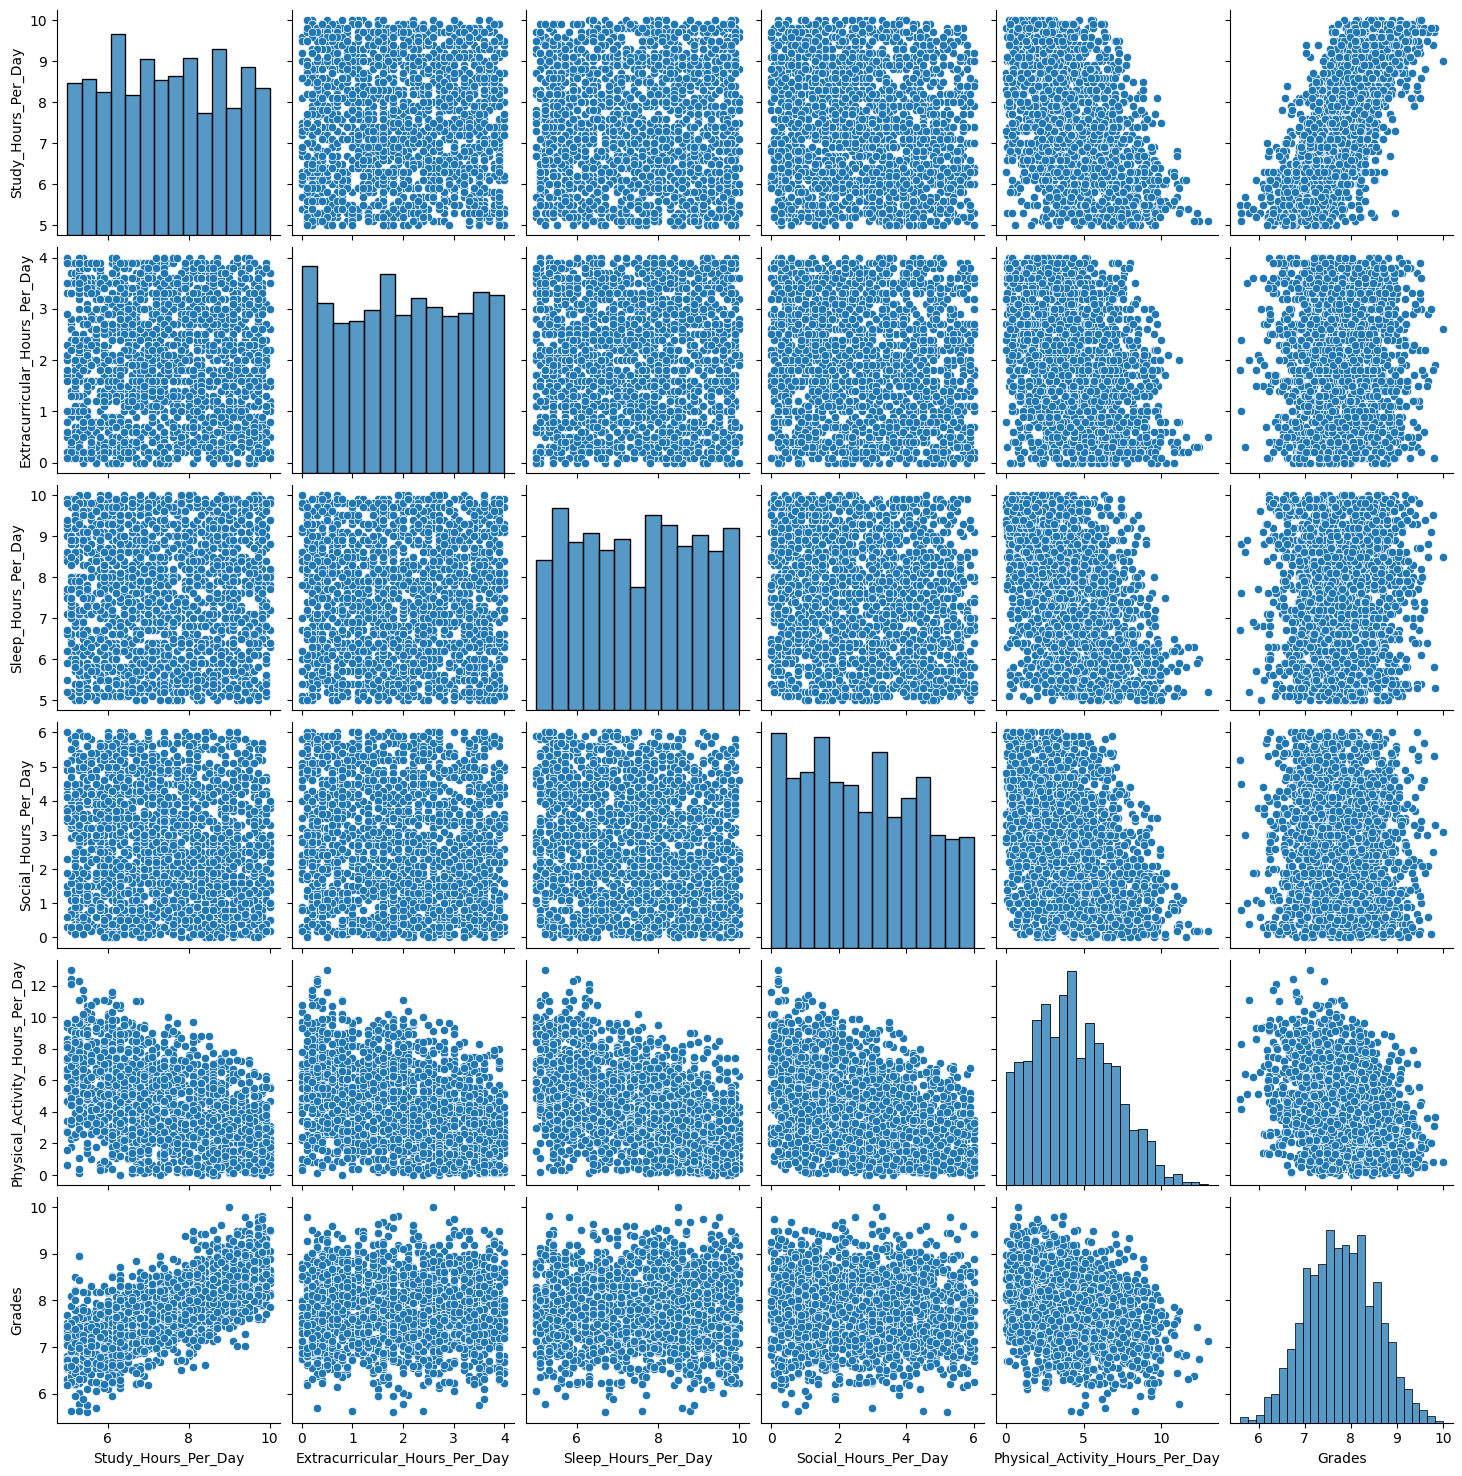

In [ ]:
sns.pairplot(numeric_df)
plt.show()

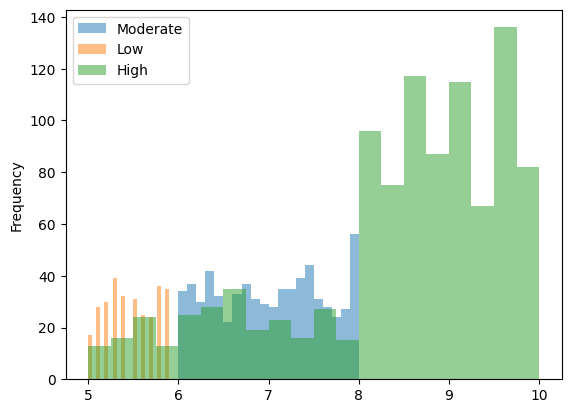

In [ ]:
for level in df['Stress_Level'].unique():
    df[df['Stress_Level'] == level]['Study_Hours_Per_Day'].plot.hist(
        bins=20, alpha=0.5, label=level
    )

plt.legend()
plt.show()

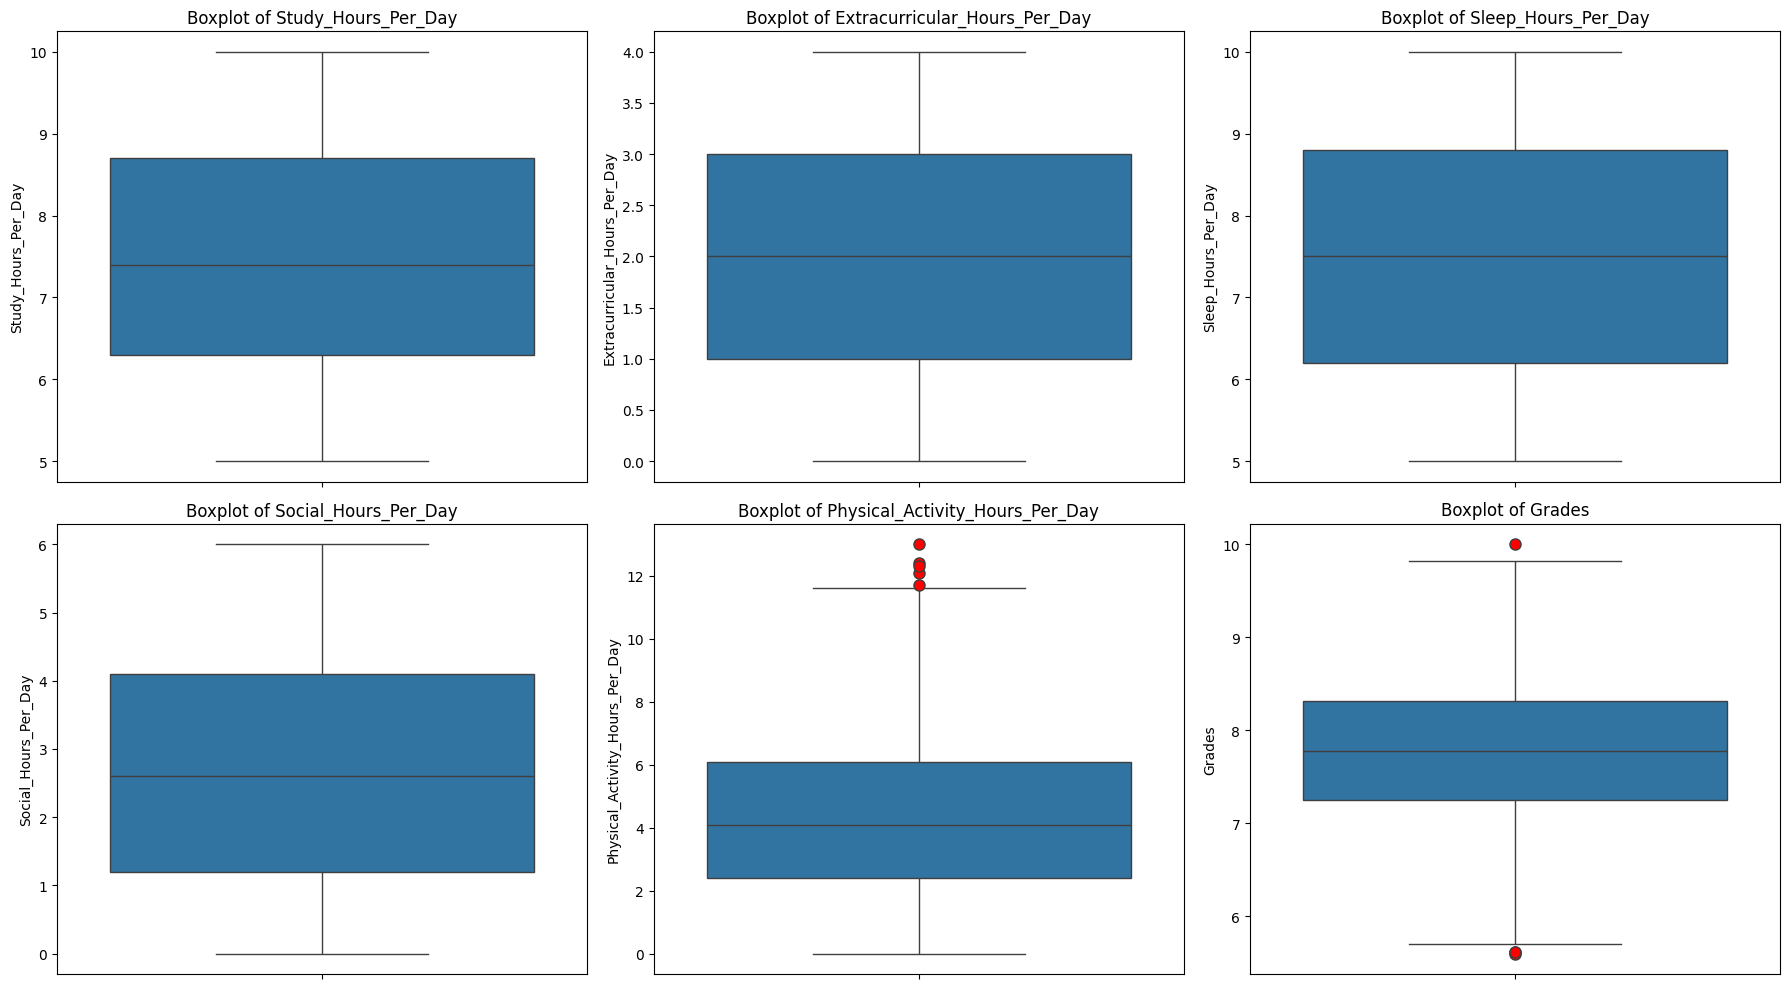

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        # Outliers
        flierprops=dict(marker='o', markerfacecolor='red', markersize=8)
    )
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [ ]:
Q1_pa = df['Physical_Activity_Hours_Per_Day'].quantile(0.25)
Q3_pa = df['Physical_Activity_Hours_Per_Day'].quantile(0.75)
IQR_pa = Q3_pa - Q1_pa
upper_bound_pa = Q3_pa + 1.5 * IQR_pa

In [ ]:
outliers_pa = df[df['Physical_Activity_Hours_Per_Day'] > upper_bound_pa]

In [ ]:
# Print basic stats
print(f"Q1: {Q1_pa:.2f}")
print(f"Q3: {Q3_pa:.2f}")
print(f"IQR: {IQR_pa:.2f}")
print(f"Upper bound: {upper_bound_pa:.2f}")
print(f"Number of outliers: {len(outliers_pa)}")

# Print the actual outlier values
print("Outlier values:")
print(outliers_pa['Physical_Activity_Hours_Per_Day'].values)

Q1: 2.40
Q3: 6.10
IQR: 3.70
Upper bound: 11.65
Number of outliers: 5
Outlier values:
[13.  12.4 12.1 12.3 11.7]


In [ ]:
Q1_grades = df['Grades'].quantile(0.25)
Q3_grades = df['Grades'].quantile(0.75)
IQR_grades = Q3_grades - Q1_grades
lower_bound_grades = Q1_grades - 1.5 * IQR_grades
outliers_grades = df[df['Grades'] < lower_bound_grades]

In [ ]:
# Print basic stats
print(f"Q1: {Q1_grades:.2f}")
print(f"Q3: {Q3_grades:.2f}")
print(f"IQR: {IQR_grades:.2f}")
print(f"lower bound: {lower_bound_grades:.2f}")
print(f"Number of outliers: {len(outliers_grades)}")

# Print the actual outlier values
print("Outlier values:")
print(outliers_grades['Grades'].values)

Q1: 7.25
Q3: 8.32
IQR: 1.07
lower bound: 5.64
Number of outliers: 3
Outlier values:
[5.62 5.6  5.62]


In [ ]:
df_original = df.copy()
df_clean = df.copy()

In [ ]:
df_clean.loc[
    df_clean['Physical_Activity_Hours_Per_Day'] > upper_bound_pa,
    'Physical_Activity_Hours_Per_Day'
] = upper_bound_pa

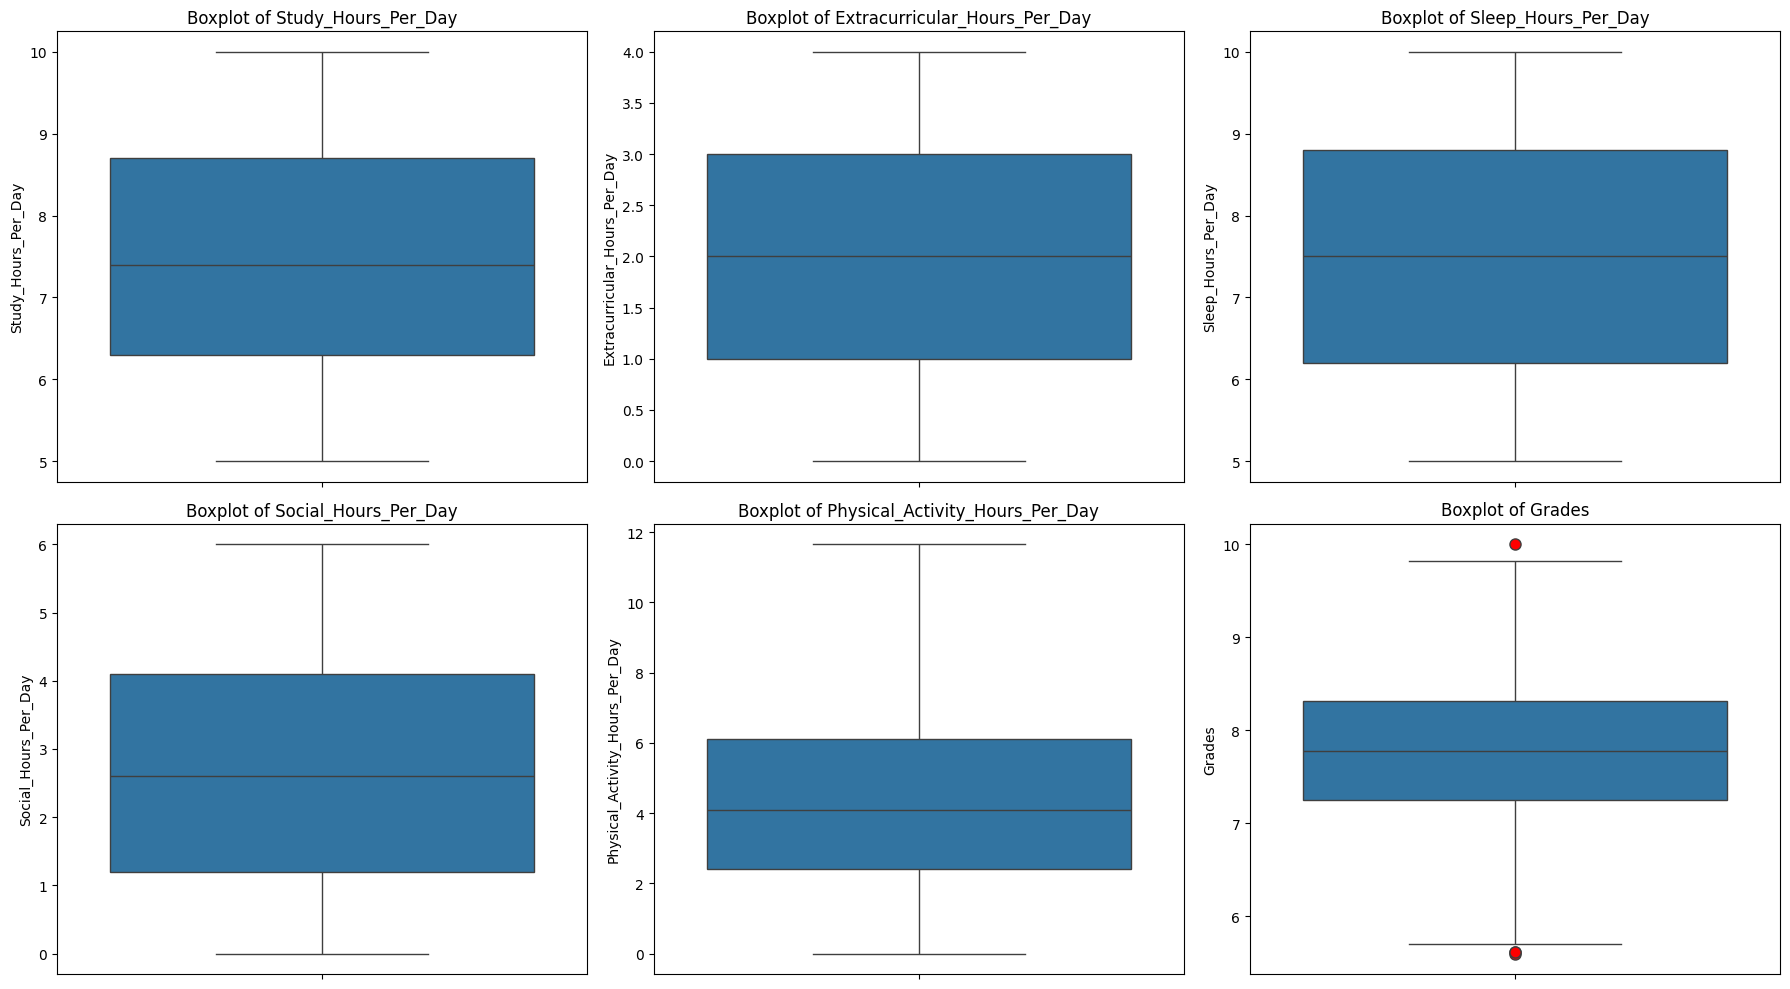

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(
        y=df_clean[col],
        ax=axes[i],
        # Outliers
        flierprops=dict(marker='o', markerfacecolor='red', markersize=8)
    )
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


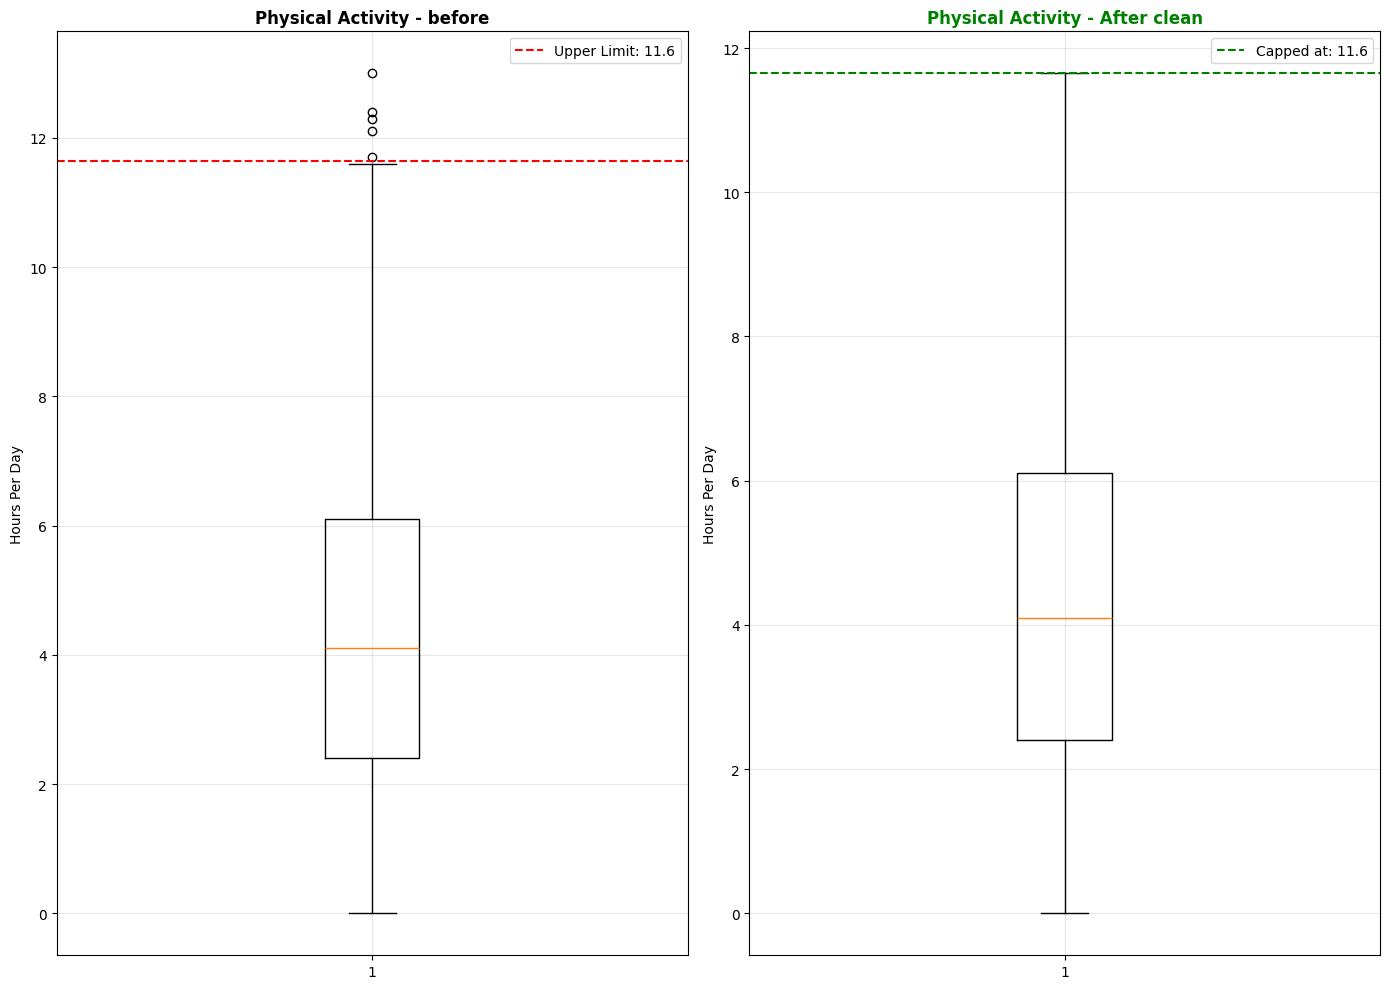

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = np.array(axes).reshape(1, 2)

# ====================================
# Physical Activity - before
# ====================================
axes[0, 0].boxplot(df_original['Physical_Activity_Hours_Per_Day'])
axes[0, 0].set_title('Physical Activity - before', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Hours Per Day')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=upper_bound_pa, color='r', linestyle='--',
                    label=f'Upper Limit: {upper_bound_pa:.1f}')
axes[0, 0].legend()

# Physical Activity - after
axes[0, 1].boxplot(df_clean['Physical_Activity_Hours_Per_Day'])
axes[0, 1].set_title('Physical Activity - After clean', fontsize=12, fontweight='bold', color='green')
axes[0, 1].set_ylabel('Hours Per Day')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=upper_bound_pa, color='g', linestyle='--',
                    label=f'Capped at: {upper_bound_pa:.1f}')
axes[0, 1].legend()


plt.tight_layout()
plt.show()


/tmp/ipython-input-2401897047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Stress_Level', y='Grades', palette='Set2')
/tmp/ipython-input-2401897047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Grades', palette='Set3')


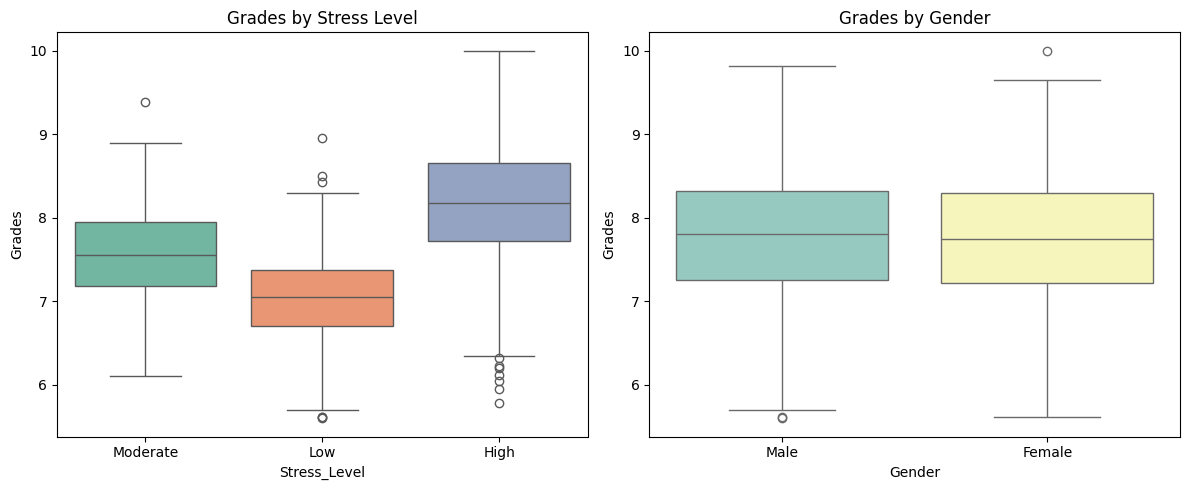

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Stress_Level', y='Grades', palette='Set2')
plt.title('Grades by Stress Level')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Gender', y='Grades', palette='Set3')
plt.title('Grades by Gender')
plt.tight_layout()
plt.show()


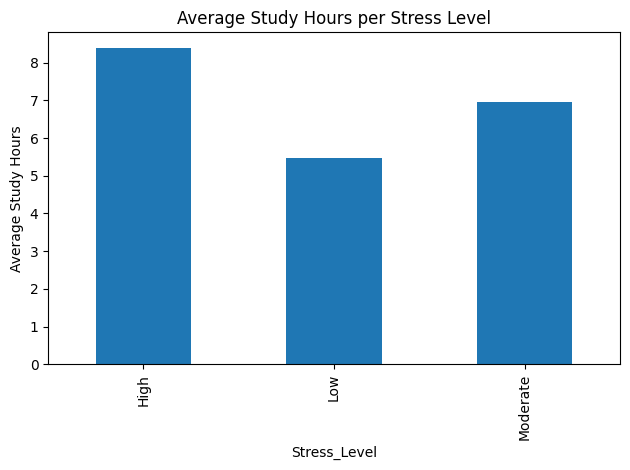

In [ ]:
df.groupby("Stress_Level")["Study_Hours_Per_Day"].mean().plot(kind="bar")
plt.ylabel("Average Study Hours")
plt.title("Average Study Hours per Stress Level")
plt.tight_layout()
plt.show()

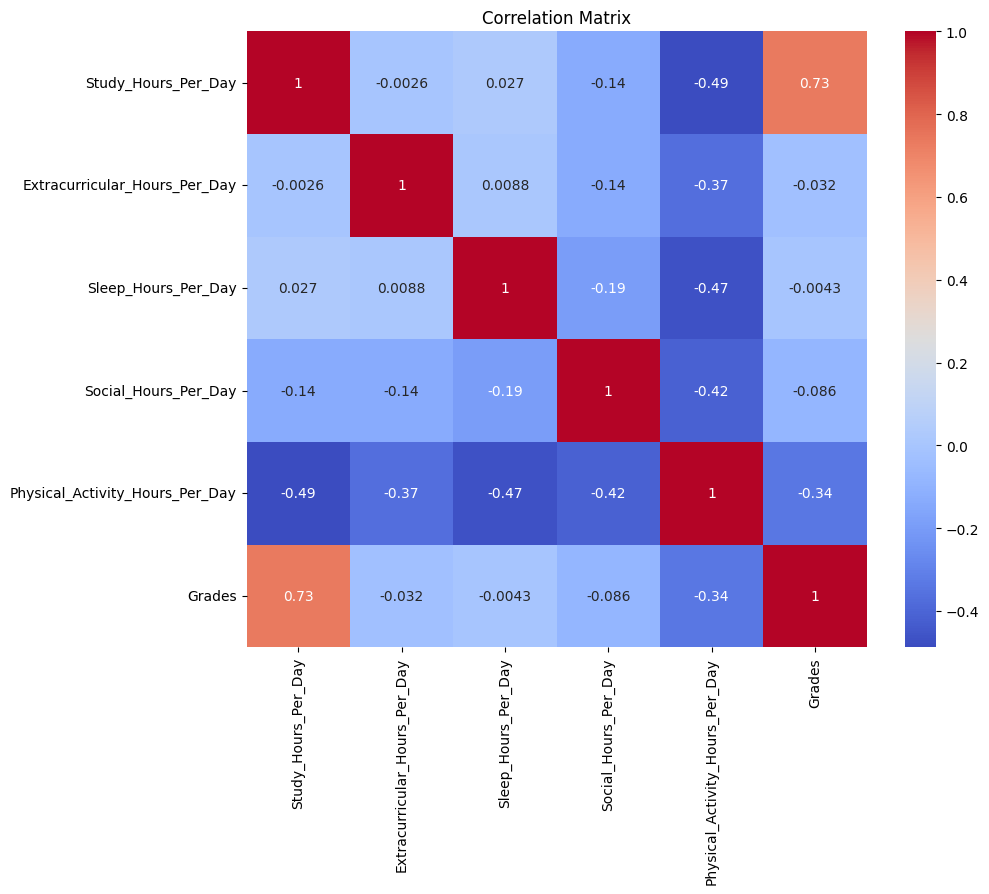

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='float64').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


numeric_df = df.select_dtypes(include=np.number)
numeric_columns = numeric_df.columns.tolist()
numeric_columns.remove('Student_ID')

In [ ]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [ ]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,2,1,7.48
1,2,5.3,3.5,8.0,4.2,3.0,1,0,6.88
2,3,5.1,3.9,9.2,1.2,4.6,1,1,6.68
3,4,6.5,2.1,7.2,1.7,6.5,2,1,7.20
4,5,8.1,0.6,6.5,2.2,6.6,0,1,8.78


In [ ]:
df['Gender'] = df['Gender'].astype(np.float64)
df['Stress_Level'] = df['Stress_Level'].astype(np.float64)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   float64
 7   Gender                           2000 non-null   float64
 8   Grades                           2000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 140.8 KB


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


# 3. Select Features & Target
X = df.drop(['Grades', 'Student_ID'], axis=1)
y = df['Grades']

# 4. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

# 6. Predict
y_pred = model.predict(X_test)

# 7. Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)


# 8. Predict new student example
sample = X.iloc[0:1]
print("Prediction Example:", model.predict(sample))

Mean Absolute Error: 0.4527739000000011
R² Score: 0.45829292743679706
Prediction Example: [7.4951]
